In [1]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
from functools import partial
from scipy.interpolate import RectBivariateSpline
from scipy.ndimage import gaussian_filter
from scipy.interpolate import interp1d
from scipy.optimize import minimize
from scipy.stats import poisson
import pandas as pd
from astropy.io import fits
from astropy.io import fits
from tqdm.notebook import tqdm

import numpyro
from jax import random
from numpyro.infer import MCMC, NUTS, Predictive
import numpyro.distributions as dist

import sys
sys.path.append("../")

from utils import create_mask as cm
from utils.pdf_sampler import PDFSampler
from models.psf import KingPSF

%load_ext autoreload
%autoreload 2

In [2]:
# Routine to project to Cartesian
from utils.cart import make_wcs, to_cart

In [3]:
# Load and downsamples Fermi counts data

counts_fits = fits.open("../data/ccube_ultracleanveto_bestpsf_joined.fits")

pixel_size_data = 0.1
pixel_size_target = 0.5
extent = 20
i_e = 40

upsample_factor = int(pixel_size_target / pixel_size_data)

counts = counts_fits[0].data[i_e:i_e + 11].sum(0)[int((90 - extent) / pixel_size_data):int((90 + extent) / pixel_size_data),int((90 - extent) / pixel_size_data):int((90 + extent) / pixel_size_data)]
b = counts.shape[0] // upsample_factor
counts_downsampled = counts.reshape(-1, upsample_factor, b, upsample_factor).sum((-1, -3))

In [4]:
extent = 20  # Semi-extent in degrees
n_pixels = 80  # Number of pixels
pixelsize = 2 * extent / n_pixels
nside = 128

# Load standard templates and convert to Cartesian
temp_gce_cart = to_cart(np.load("../data/fermi_data/template_gce.npy"), n_pixels=n_pixels, pixelsize=pixelsize)
temp_dif_cart = to_cart(np.load("../data/fermi_data/template_dif.npy"), n_pixels=n_pixels, pixelsize=pixelsize)
temp_psc_cart = to_cart(np.load("../data/fermi_data/template_psc.npy"), n_pixels=n_pixels, pixelsize=pixelsize)
temp_iso_cart = to_cart(np.load("../data/fermi_data/template_iso.npy"), n_pixels=n_pixels, pixelsize=pixelsize)
temp_dsk_cart = to_cart(np.load("../data/fermi_data/template_dsk.npy"), n_pixels=n_pixels, pixelsize=pixelsize)
temp_bub_cart = to_cart(np.load("../data/fermi_data/template_bub.npy"), n_pixels=n_pixels, pixelsize=pixelsize)
mask_ps = np.load("../data/fermi_data/fermidata_pscmask.npy") == 1

# Load Model O templates
temp_mO_pibrem_cart = to_cart(np.load("../data/fermi_data/ModelO_r25_q1_pibrem.npy"), n_pixels=n_pixels, pixelsize=pixelsize)
temp_mO_ics_cart = to_cart(np.load("../data/fermi_data/ModelO_r25_q1_ics.npy"), n_pixels=n_pixels, pixelsize=pixelsize)

mask_roi = to_cart(cm.make_mask_total(nside=nside, band_mask=True, band_mask_range=2., mask_ring=True, inner=0, outer=20., custom_mask=mask_ps), n_pixels=n_pixels, pixelsize=pixelsize) > 0
mask_plane = to_cart(cm.make_mask_total(nside=nside, band_mask=True, band_mask_range=2., mask_ring=True, inner=0, outer=20.,), n_pixels=n_pixels, pixelsize=pixelsize) > 0

In [5]:
from einops import rearrange

In [6]:
def model(data):
    
    
    A_gce = numpyro.sample("A_gce", dist.Uniform(0.0, 20.0))
    A_iso = numpyro.sample("A_iso", dist.Uniform(0.0, 20.0))
    A_bub = numpyro.sample("A_bub", dist.Uniform(0.0, 20.0))
    A_psc = numpyro.sample("A_psc", dist.Uniform(0.0, 20.0))
    A_dif = numpyro.sample("A_dif", dist.Uniform(0.0, 50.0))
    
    mu = A_gce * temp_gce_cart + A_iso * temp_iso_cart + A_dif * temp_dif_cart + \
        A_psc * temp_psc_cart + A_bub * temp_bub_cart
    
    data_flattened = rearrange(data, 'x y -> (x y)', x=80)
    mu_flattened = rearrange(mu, 'x y -> (x y)', x=80)
    
    with numpyro.plate("data", len(mu_flattened)):
        numpyro.sample("obs", dist.Poisson(mu_flattened), obs=data_flattened)


In [7]:
nuts_kernel = NUTS(model)

mcmc = MCMC(nuts_kernel, num_samples=2000, num_warmup=2000)
rng_key = random.PRNGKey(0)
mcmc.run(rng_key, counts_downsampled)


sample: 100%|██████████| 4000/4000 [00:12<00:00, 326.62it/s, 7 steps of size 4.94e-01. acc. prob=0.89] 


In [8]:
import corner
import arviz as az

In [9]:
arviz_post = az.from_numpyro(mcmc)

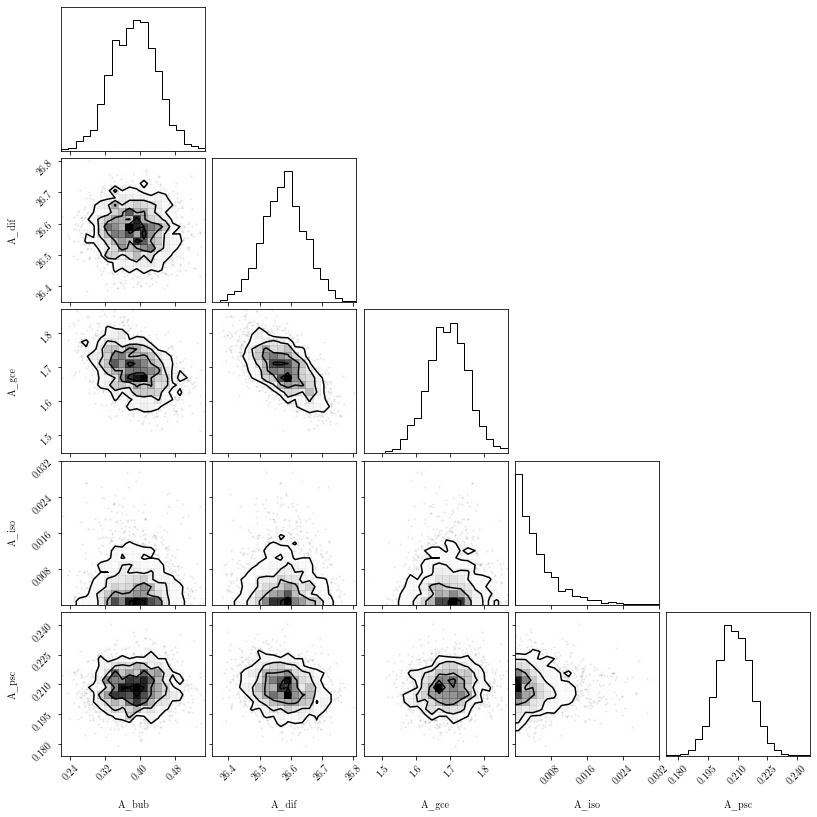

In [10]:
corner.corner(arviz_post);

## Variable $\gamma$

In [11]:
import jax.numpy as jnp
from jax import jit, vmap

In [194]:
def mod(dividends, divisor):
    """ Return dividends (array) mod divisor (double)
        Stolen from Nick's code
    """

    output = np.zeros(len(dividends))

    for i in range(len(dividends)): 
        output[i] = dividends[i]
        done=False
        while (not done):
            if output[i] >= divisor:
                output[i] -= divisor
            elif output[i] < 0.:
                output[i] += divisor
            else:
                done=True

    return output


def rho_NFW(r, gamma=1., r_s=20.):
    """ Generalized NFW profile
    """
    return (r / r_s) ** -gamma * (1 + (r / r_s)) ** (-3 + gamma) 

def rGC(s_ary, b_ary, l_ary, rsun=8.224):
    """ Distance to GC as a function of LOS distance, latitude, longitude
    """
    return jnp.sqrt(s_ary ** 2 - 2. * rsun * jnp.transpose(jnp.outer(s_ary, jnp.cos(b_ary) * jnp.cos(l_ary))) + rsun ** 2)

pixel_size = 0.5
extent = 20

coords_ary = jnp.deg2rad(jnp.arange(-extent, extent, pixel_size))
l_ary, b_ary = jnp.meshgrid(coords_ary, coords_ary)

npix = int(len(coords_ary) ** 2)

l_ary_flat = rearrange(l_ary, 'x y -> (x y)')
b_ary_flat = rearrange(b_ary, 'x y -> (x y)')

s_ary = jnp.linspace(0, 20, 200)

In [195]:
@jit
def get_NFW2_template_cart(gamma=1.2):
    # LOS integral of density^2
    int_rho2 = jnp.trapz(rho_NFW(rGC(s_ary, b_ary_flat, l_ary_flat), gamma=gamma) ** 2, s_ary, axis=1)
    int_rho2 = rearrange(int_rho2, '(x y) -> x y', x=len(coords_ary))
    return int_rho2 / 1000 # / jnp.mean(int_rho2[~mask_roi])

In [196]:
from utils import create_mask as cm

mask_roi = to_cart(cm.make_mask_total(nside=nside, band_mask=True, band_mask_range=2., mask_ring=True, inner=0, outer=20., custom_mask=mask_ps), n_pixels=n_pixels, pixelsize=pixelsize) > 0
mask_plane = to_cart(cm.make_mask_total(nside=nside, band_mask=True, band_mask_range=2., mask_ring=True, inner=0, outer=20.,), n_pixels=n_pixels, pixelsize=pixelsize) > 0

In [200]:
def model(data):
    
    data_flattened = rearrange(data, 'x y -> (x y)', x=80)
    
    A_gce = numpyro.sample("A_gce", dist.Uniform(0.0, 10.0))
    A_iso = numpyro.sample("A_iso", dist.Uniform(0.0, 10.0))
    A_bub = numpyro.sample("A_bub", dist.Uniform(0.0, 10.0))
    A_psc = numpyro.sample("A_psc", dist.Uniform(0.0, 10.0))
    A_dif = numpyro.sample("A_dif", dist.Uniform(0.0, 50.0))

    gamma = numpyro.sample("gamma", dist.Uniform(0.1, 2.0))

    temp_gce_jax = get_NFW2_template_cart(gamma=gamma)

    mu = A_gce * temp_gce_jax + A_iso * temp_iso_cart + A_dif * temp_dif_cart + \
        A_psc * temp_psc_cart + A_bub * temp_bub_cart


    mu_flattened = rearrange(mu, 'x y -> (x y)', x=80)
    
    mask_flattened = rearrange(mask_roi, 'x y -> (x y)', x=80)

    with numpyro.plate("data", len(mu_flattened[~mask_flattened])):

        numpyro.sample("obs", dist.Poisson(mu_flattened[~mask_flattened]), obs=data_flattened[~mask_flattened])

In [201]:
# nuts_kernel = NUTS(model, dense_mass=True, max_tree_depth=3)

# mcmc = MCMC(nuts_kernel, num_samples=2000, num_warmup=500)
# rng_key = random.PRNGKey(0)
# mcmc.run(rng_key, counts_downsampled)

In [202]:
# arviz_post = az.from_numpyro(mcmc)
# corner.corner(arviz_post);

In [221]:
from numpyro.infer import SVI, Predictive, Trace_ELBO, RenyiELBO, autoguide

In [222]:
guide = autoguide.AutoMultivariateNormal(model)

optimizer = numpyro.optim.Adam(0.01)
svi = SVI(model, guide, optimizer, RenyiELBO(num_particles=1))
svi_results = svi.run(random.PRNGKey(1), 4000, counts_downsampled)
params = svi_results.params

100%|██████████| 4000/4000 [02:27<00:00, 27.09it/s, init loss: 149553.5625, avg. loss [3801-4000]: 13216.7002]


In [223]:
predictive = Predictive(
            model=model, guide=guide, params=params, num_samples=2000
        )

predictions = predictive(random.PRNGKey(0), data=counts_downsampled)


In [224]:
posterior = guide.sample_posterior(rng_key=random.PRNGKey(0), params=params, sample_shape=(2000, 6))

/Users/smsharma/anaconda3/lib/python3.8/site-packages/arviz/data/base.py:220: UserWarning: More chains (2000) than draws (6). Passed array should have shape (chains, draws, *shape)
  warnings.warn(


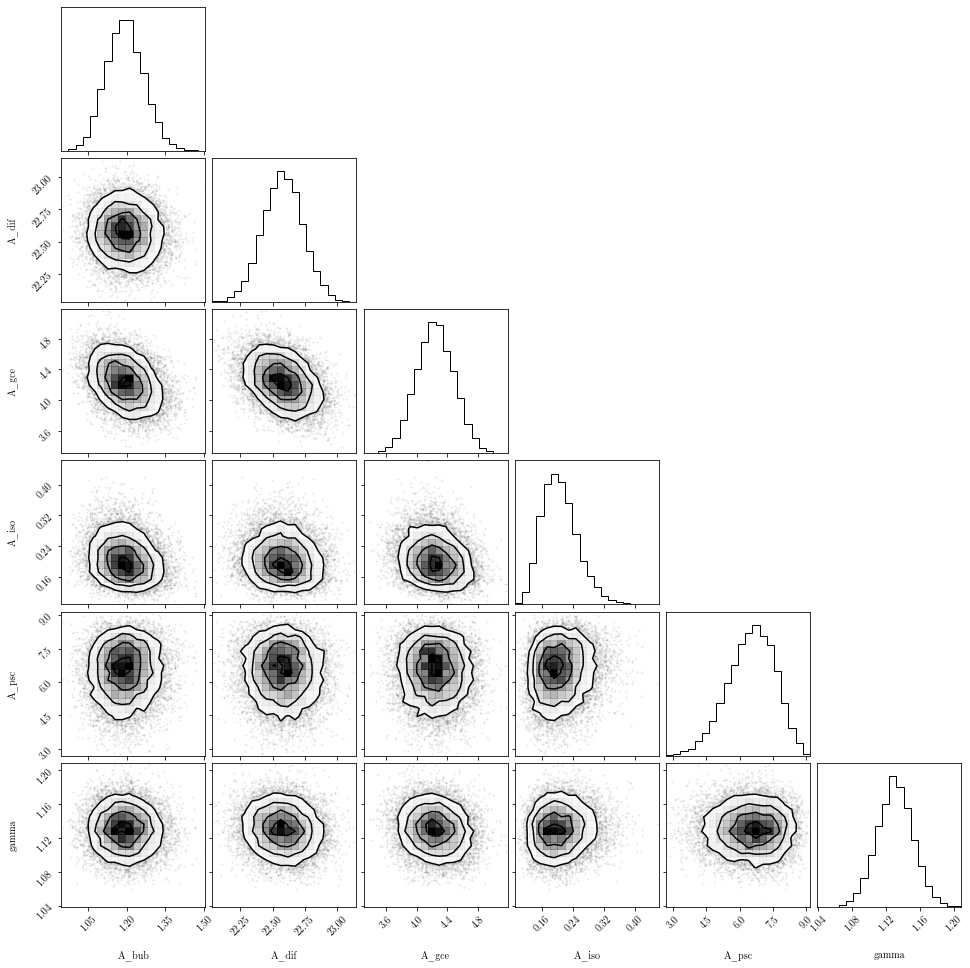

In [225]:
arviz_post = az.from_dict(posterior)
corner.corner(arviz_post);